## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


torch.Size([28, 28])


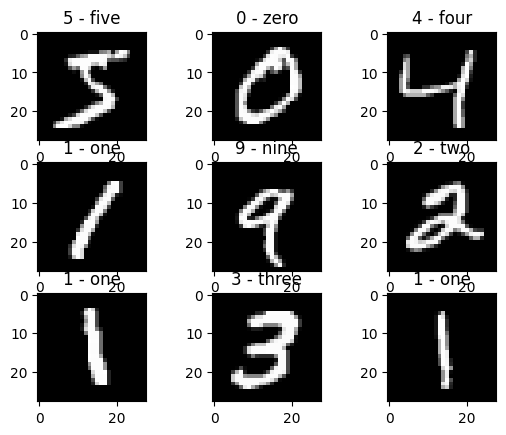

In [2]:
# Transform 정의 (MNIST는 28x28, 1 Channel)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # 1채널 정규화
])

# 데이터셋 다운로드 및 로드
train_data = datasets.MNIST(root='./data/', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data/', train=False, download=True, transform=transform)

# 데이터 확인용 출력 (1채널이므로 cmap='gray' 추가)
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i], cmap='gray')
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

## Modeling

In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        # [과제 충족] Batch Normalization 추가
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x) # BN 적용
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x) # BN 적용
        x = self.relu(x)
        x = self.pool(x)
        return x

In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # 256 channel * 3 * 3 = 2304
        self.fc1 = nn.Linear(in_features=256 * 3 * 3, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        # Dropout 추가
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

        # Initialization (He Initialization)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x) # Dropout 적용

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x) # Dropout 적용

        x = self.fc3(x)
        return x

In [5]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cuda


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(12

In [6]:
# Early Stopping 설정
patience = 3
counter = 0
best_loss = float('inf')

# Learning rate & Optimizer
lr = 1e-3
optim = Adam(model.parameters(), lr=lr)

# Train loop
for epoch in range(20): # Epoch을 적당히 조절 (Early Stopping이 있으므로 넉넉히 20~30)
    model.train() # 학습 모드
    for data, label in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optim.zero_grad()
        preds = model(data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    # Validation(Test) Loss 확인 및 Early Stopping
    model.eval() # 평가 모드
    test_loss = 0
    with torch.no_grad():
        for data, label in test_loader:
            preds = model(data.to(device))
            test_loss += nn.CrossEntropyLoss()(preds, label.to(device)).item()

    test_loss /= len(test_loader)
    print(f"Epoch {epoch+1} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss:.4f}")

    # Early Stopping Logic
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), "MNIST_CNN_Best.pth") # 최고 성능 모델 저장
    else:
        counter += 1
        print(f"EarlyStopping counter: {counter} out of {patience}")
        if counter >= patience:
            print("Early Stopping triggered.")
            break

Epoch 1: 100%|██████████| 938/938 [00:18<00:00, 50.84it/s]


Epoch 1 | Train Loss: 0.0037 | Test Loss: 0.0385


Epoch 2: 100%|██████████| 938/938 [00:18<00:00, 50.85it/s]


Epoch 2 | Train Loss: 0.0091 | Test Loss: 0.0369


Epoch 3: 100%|██████████| 938/938 [00:17<00:00, 52.69it/s]


...

Epoch 4 | Train Loss: 0.0030 | Test Loss: 0.0317
EarlyStopping counter: 1 out of 3


Epoch 5: 100%|██████████| 938/938 [00:20<00:00, 46.61it/s]


Epoch 5 | Train Loss: 0.1968 | Test Loss: 0.0429
EarlyStopping counter: 2 out of 3


Epoch 6: 100%|██████████| 938/938 [00:17<00:00, 55.10it/s]


Epoch 6 | Train Loss: 0.0018 | Test Loss: 0.0272
EarlyStopping counter: 3 out of 3
Early Stopping triggered.


In [7]:
model.load_state_dict(torch.load("MNIST_CNN_Best.pth"))
model.eval()

num_corr = 0
with torch.no_grad():
    for data, label in test_loader:
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        num_corr += preds.eq(label.to(device)).sum().item()

print(f"최종 테스트 정확도: {num_corr/len(test_data)*100:.2f}%")

최종 테스트 정확도: 99.30%


최적 성능 도달: Epoch 3에서 Test Loss 0.0234로 가장 낮은 수치를 기록하며 최적 모델이 저장됨.

Early Stopping 작동:

Epoch 3 이후 Test Loss가 정체됨.
따라서 설정한 Patience(3회)를 충족하여 Epoch 6에서 학습이 자동 조기 종료